In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X,y = make_classification(
    n_samples=1000,
    n_features=2,# 2維才能畫圖
    n_informative=2,# 兩個特徵都有用
    class_sep=2.0,# 分得更開（越大越好分）
    n_clusters_per_class=1,#變成2個區塊0與1
    random_state=0,
    n_redundant=0#不要複製特徵值 預設為2 
)

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((750, 2), (250, 2), (750,), (250,))

Text(0.5, 1.0, 'Testing Data')

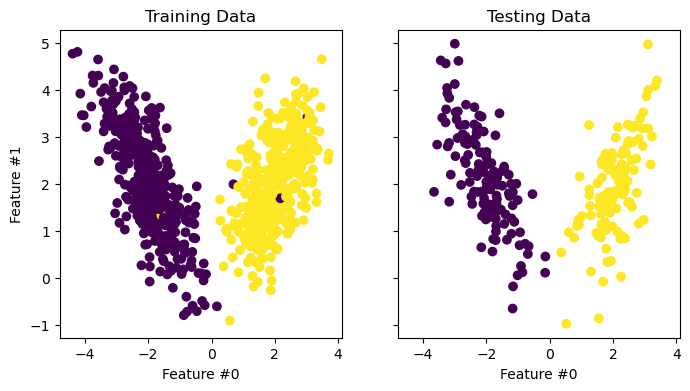

In [35]:
_,(train_ax,test_ax) = plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(8,4))
train_ax.scatter(X_train[:,0],X_train[:,1],c=y_train)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training Data")


test_ax.scatter(X_test[:,0],X_test[:,1],c=y_test)
test_ax.set_xlabel("Feature #0")
test_ax.set_title("Testing Data")

Text(0.5, 1.0, 'Test Data (PCA)')

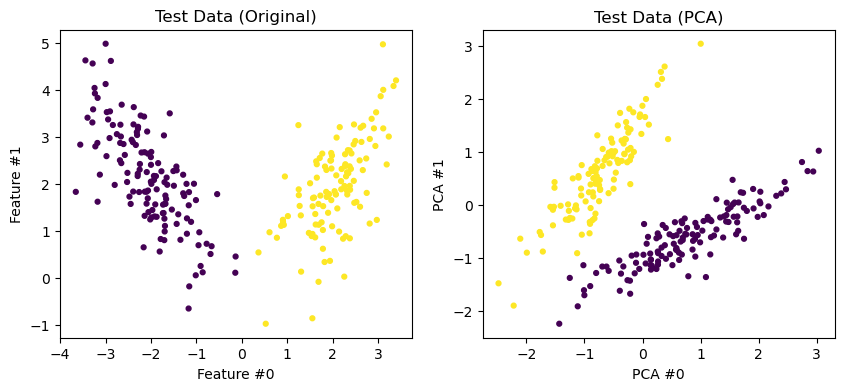

In [44]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
pca = PCA(n_components=2,random_state=0)
X_test_pca = pca.fit(X_train_std).transform(X_test_std)
_,(orig_data_ax,pca_proj_ax) = plt.subplots(ncols=2,figsize=(10,4))

orig_data_ax.scatter(X_test[:,0],X_test[:,1],c = y_test,s = 12)
orig_data_ax.set_ylabel("Feature #1")
orig_data_ax.set_xlabel("Feature #0")
orig_data_ax.set_title("Test Data (Original)")

pca_proj_ax.scatter(X_test_pca[:,0],X_test_pca[:,1],c=y_test,s = 12)
pca_proj_ax.set_ylabel("PCA #1")
pca_proj_ax.set_xlabel("PCA #0")
pca_proj_ax.set_title("Test Data (PCA)")

In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
# 資料切割
#stratify=y 分層抽樣 每一類案y的樣子抽樣
"""
stratify=y：原始數據集（y）中有70%的數據是類別0，
和30%的數據是類別1，那麼使用stratify=y參數後，
訓練集和測試集中的數據也會儘量保持這個70%/30%的比例
"""
#factor=0.5 小圓是大圓的一半小
X,y = make_circles(n_samples=1000,noise=0.05,random_state=0,factor=0.5)
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((750, 2), (250, 2), (750,), (250,))

Text(0.5, 1.0, 'Testing Data')

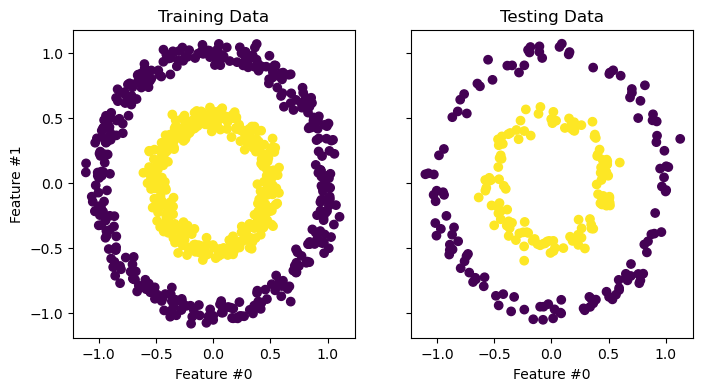

In [51]:
_,(train_ax,test_ax) = plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(8,4))
train_ax.scatter(X_train[:,0],X_train[:,1],c=y_train)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training Data")

test_ax.scatter(X_test[:,0],X_test[:,1],c=y_test)
test_ax.set_xlabel("Feature #0")
test_ax.set_title("Testing Data")

In [52]:
from sklearn.decomposition import PCA,KernelPCA
pca = PCA(n_components=2,random_state=0)
X_test_pca = pca.fit(X_train).transform(X_test)

Text(0.5, 1.0, 'Test Data (PCA)')

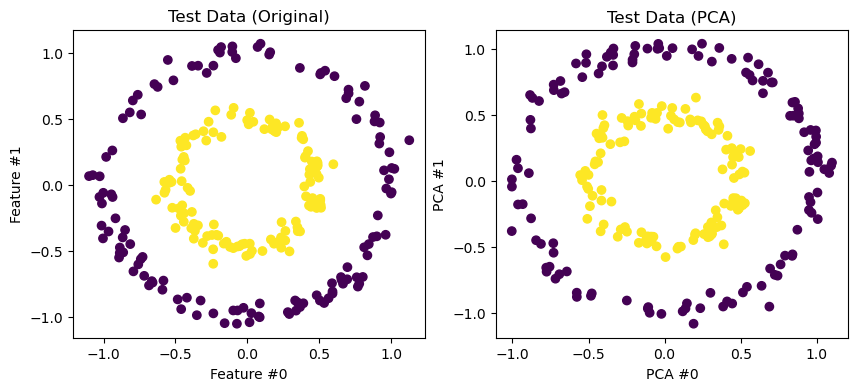

In [53]:
_,(orig_data_ax,pca_proj_ax) = plt.subplots(ncols=2,figsize=(10,4))
orig_data_ax.scatter(X_test[:,0],X_test[:,1],c = y_test)
orig_data_ax.set_ylabel("Feature #1")
orig_data_ax.set_xlabel("Feature #0")
orig_data_ax.set_title("Test Data (Original)")

pca_proj_ax.scatter(X_test_pca[:,0],X_test_pca[:,1],c=y_test)
pca_proj_ax.set_ylabel("PCA #1")
pca_proj_ax.set_xlabel("PCA #0")
pca_proj_ax.set_title("Test Data (PCA)")

In [54]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler

## KernelPCA 萃取特徵
kernel參數說明
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html

linear：線性核。這實際上與普通的PCA相同。

poly：多項式核。這個核有額外的參數（如：多項式的程度、係數等）來控制多項式的特性。

rbf：半徑向基函數（Radial Basis Function）核。這是一個常用的核，適用於各種非線性問題。

sigmoid：S型核。這個核經常用在神經網絡和支持向量機中。

cosine：餘弦相似性核。這個核基於兩個向量之間的餘弦相似性。

precomputed：如果您已經計算了核矩陣，可以使用這個選項。

callable：如果你有一個自定義的核函數，你可以直接將其作為這個參數的值。


KernelPCA 像什麼？

先把紙揉一揉、拉一拉，把彎曲的形狀攤平，再照影子
所以它能處理「非線性」形狀。

## 因為 KernelPCA（rbf）是 非線性，它投影到的是「新的特徵空間座標」，所以圖形長相會變。

Text(0.5, 1.0, 'Testing Data')

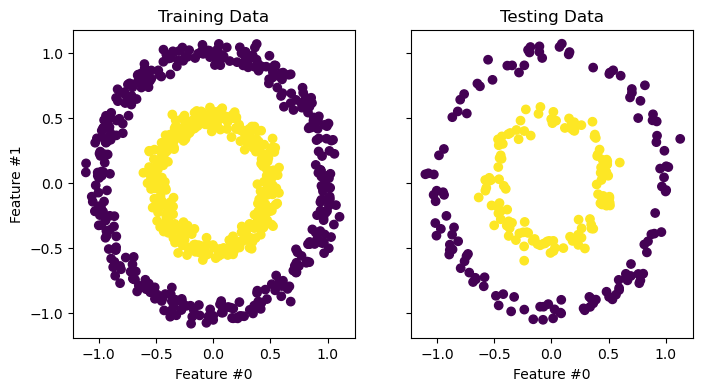

In [55]:
X,y = make_circles(n_samples=1000,noise=0.05,random_state=0,factor=0.5)
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape
_,(train_ax,test_ax) = plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(8,4))
train_ax.scatter(X_train[:,0],X_train[:,1],c=y_train)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training Data")

test_ax.scatter(X_test[:,0],X_test[:,1],c=y_test)
test_ax.set_xlabel("Feature #0")
test_ax.set_title("Testing Data")

In [56]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


In [57]:
KernelPCA = KernelPCA(n_components=2,kernel="rbf",gamma=10)#非線性要多曲折
X_test_kernel_pca =  KernelPCA.fit(X_train_std).transform(X_test_std)


Text(0.5, 1.0, 'Test Data (KPCA)')

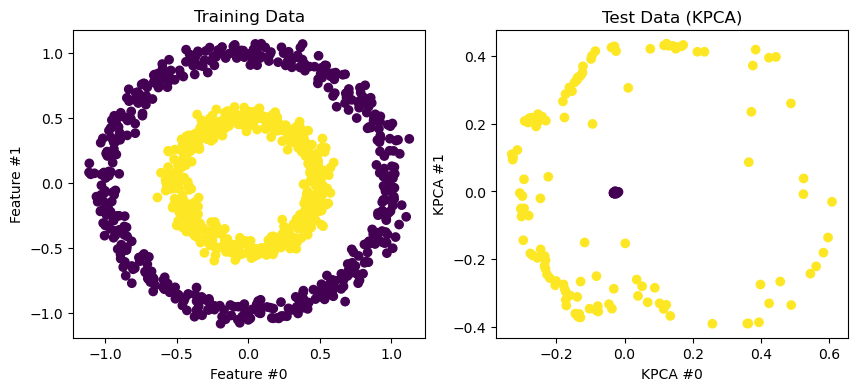

In [59]:
_,(orig_data_ax,kernal_pca_project_ax) = plt.subplots(ncols=2,figsize=(10,4))
orig_data_ax.scatter(X_test[:,0],X_test[:,1],c = y_test)
orig_data_ax.scatter(X_train[:,0],X_train[:,1],c=y_train)
orig_data_ax.set_ylabel("Feature #1")
orig_data_ax.set_xlabel("Feature #0")
orig_data_ax.set_title("Training Data")


kernal_pca_project_ax.scatter(X_test_kernel_pca[:,0],X_test_kernel_pca[:,1],c=y_test)
kernal_pca_project_ax.set_ylabel("KPCA #1")
kernal_pca_project_ax.set_xlabel("KPCA #0")
kernal_pca_project_ax.set_title("Test Data (KPCA)")

## 使用線性測試資料羅吉斯回歸

In [63]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# 1) 線性可分資料（2D）
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,      # 越大越好分（線性）
    flip_y=0.03,        # 加一點雜訊(可改 0 或 0.05)
    random_state=0
)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.35,random_state=42,stratify=y)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1300, 2), (700, 2), (1300,), (700,))

In [64]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
pca = PCA(n_components=2,random_state=0)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca,y_train)
pca_pred =  clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test,pca_pred)


print(f"PCA:{acc_pca}")

PCA:0.9757142857142858


In [68]:
kpca = KernelPCA(n_components=2,kernel="rbf",gamma=60)
X_train_kpca = kpca.fit_transform(X_train_std)
X_test_kpca = kpca.transform(X_test_std)
clf_kpca = LogisticRegression()
clf_kpca.fit(X_train_kpca,y_train)
kpca_pred =  clf_kpca.predict(X_test_kpca)
acc_kpca = accuracy_score(y_test,kpca_pred)

print(f"KPCA:{acc_kpca}")

KPCA:0.6142857142857143


## 使用同心圓測試資料羅吉斯回歸

In [70]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) 非線性資料：同心圓
X, y = make_circles(n_samples=2000, factor=0.4, noise=0.06, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y
)


# 2) 標準化（很重要，KernelPCA 很吃尺度）
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

pca = PCA(n_components=2,random_state=0)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca,y_train)
pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test,pred_pca)
print(f"PCA_ACC:{acc_pca}")

PCA_ACC:0.46285714285714286


In [80]:
kpca = KernelPCA(n_components=2,kernel="rbf",gamma=10)
X_train_kpca = kpca.fit_transform(X_train_std)
X_test_kpca = kpca.transform(X_test_std)
clf_kpca = LogisticRegression()
clf_kpca.fit(X_train_kpca,y_train)
pred_kpca = clf_kpca.predict(X_test_kpca)
acc_kpca = accuracy_score(y_test,pred_kpca)
print(f"KPCA_ACC:{acc_kpca}")

KPCA_ACC:0.6857142857142857


# LDA 監督示
它找一條（或幾條）線，讓不同類別的人在投影後分得最開、同一類的人聚得最緊。